In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   

In [3]:
# Ok let's do PCA
def getPairwiseDists(systems,datasets,selection_strings,stride = 10,EQPOINT=250):
    
    alldists=[]
    for i in range(len(datasets)):
        subdists=[]
        for j in range(len(datasets[i])):
            distances=[]
            for k in range(int(EQPOINT/stride),int(len(systems[i][j].trajectory)/stride)):
                systems[i][j].trajectory[k*stride]
                distances.append(MDAnalysis.analysis.distances.self_distance_array(datasets[i][j].select_atoms("name CA").positions))
            subdists.append(distances)
        alldists.append(subdists)
    return alldists


In [4]:

dists = getPairwiseDists(systems,v1s,v1strings,stride = 1,EQPOINT=EQPOINT)







In [5]:
#save("allpcadists-V1-CApairwise.npy",dists)
dists=load("allpcadists-V1-CApairwise.npy")

shaped_dists=[]
pca_colours = []
for i in range(len(dists)):
    for j in range(len(dists[i])):
        for k in range(len(dists[i][j])):
            shaped_dists.append(dists[i][j][k])
            pca_colours.append(colourScheme[i])
            
            

Z=sklearn.preprocessing.StandardScaler().fit_transform(shaped_dists)

myPCA=sklearn.decomposition.PCA(n_components=2)
myfit=myPCA.fit(Z)
pcaX=myPCA.transform(Z)
pcaPoints= pcaX.T

In [52]:
#Create a scaler
scaler = sklearn.preprocessing.StandardScaler()
# Fit scaler with the distances from the structures
scaler.fit(shaped_dists)
# get the mean and scale of this transformation
scale_final = scaler.scale_
mean_final = scaler.mean_


scaled_dists = (copy(dists) - mean_final)/scale_final
transformed_dists = []
for i in range(len(scaled_dists)):
    sub=[]
    for j in range(len(scaled_dists[i])):
        sub.append(myPCA.transform(scaled_dists[i][j]))
        
    transformed_dists.append(sub)
    
    
nmrStructures = glob.glob("../3_System_setup/alphafold_narval/systems/wt_rht5a/models/*.pdb")
my_selections_nmr = []
for i in range(len(nmrStructures)):
    my_selections_nmr.append(mda.Universe(nmrStructures[i]).select_atoms("resid 292:495"))
    
nmrSelStringV1 = "name CA and resid 326:349 and not resid 337 and not resid 338"
nmrV1s=[]
for i in range(len(nmrStructures)):
    nmrV1s.append(my_selections_nmr[i].select_atoms(nmrSelStringV1))
    
    
    
nmrV1_dists=[]    
for i in range(len(nmrV1s)):
    nmrV1_dists.append(MDAnalysis.analysis.distances.self_distance_array(nmrV1s[i].select_atoms("name CA").positions))
    
nmrV1_dists_scaled = (array(nmrV1_dists) - mean_final)/scale_final
nmrV1_dists_scaled_transformed=[]
nmrV1_dists_scaled_transformed=myPCA.transform(nmrV1_dists_scaled)

Text(0.5, 0, 'PC1')

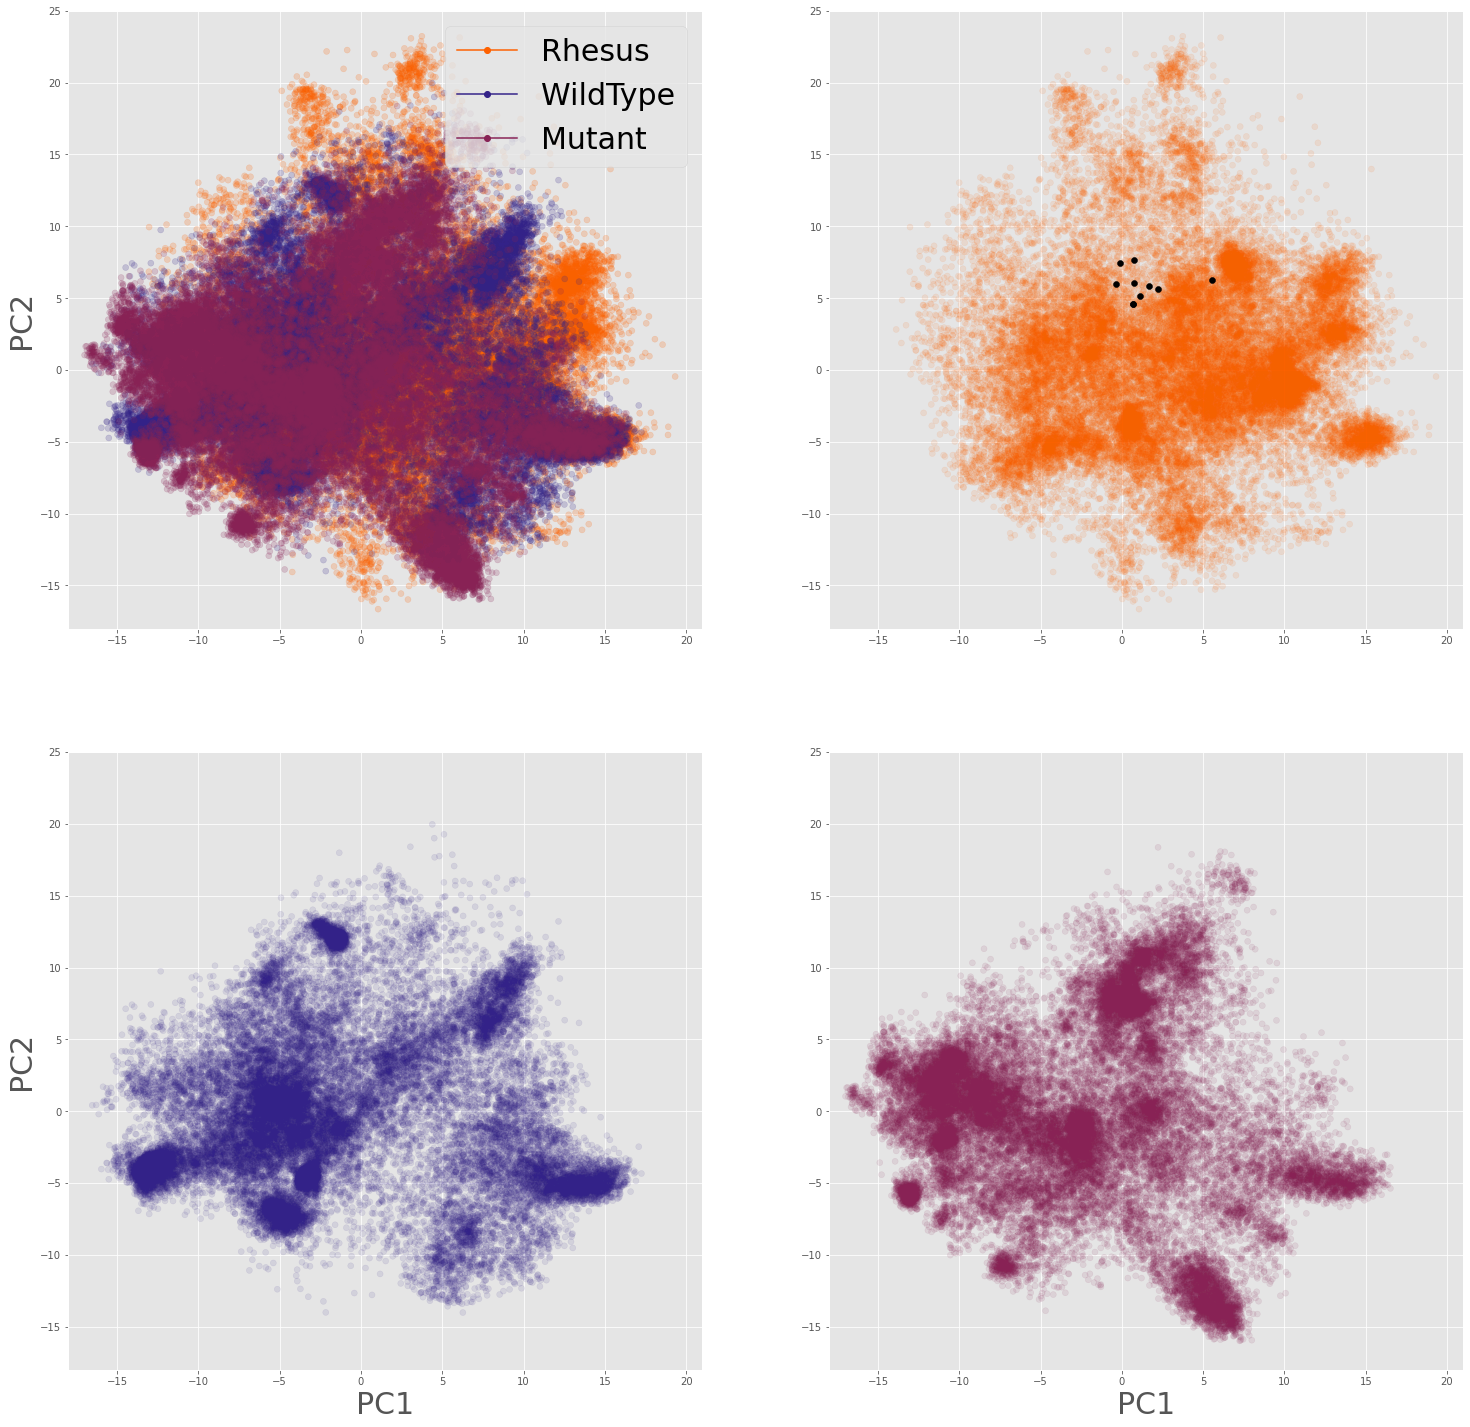

In [53]:
style.use("ggplot")
figure(figsize = (25,25))
#for i in range(len(pcaPoints.T)):
#    scatter(pcaPoints.T[i][0],pcaPoints.T[i][1],color = pca_colours[i],alpha = 0.1)#,color = mycolors[i])#,label = structureList[i][3:])

subplot(2,2,1)
scatter(*pcaPoints,color = pca_colours,alpha = 0.2)
legend_elements = [Line2D([0], [0], marker='o', color=colourScheme[0], label="Rhesus"),
                       Line2D([0], [0], marker='o', color=colourScheme[1], label="WildType"),
                       Line2D([0], [0], marker='o', color=colourScheme[2], label="Mutant")]
legend(handles = legend_elements,loc='best',fontsize = 30)
ylabel("PC2",fontsize = 30)
ylim(-18,25)
xlim(-18,21)
#xticks([])
#yticks([])

subplot(2,2,2)
scatter(pcaPoints[0][:int(len(pcaPoints[0])/3)],pcaPoints[1][:int(len(pcaPoints[0])/3)],color = pca_colours[:int(len(pcaPoints[0])/3)],alpha = 0.1)
scatter(*nmrV1_dists_scaled_transformed.T,color = "black")
#xticks([])
#yticks([])
ylim(-18,25)
xlim(-18,21)

subplot(2,2,3)
scatter(pcaPoints[0][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],pcaPoints[1][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],color = pca_colours[int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],alpha = 0.1)

#xticks([])
#yticks([])
ylim(-18,25)
xlim(-18,21)
xlabel("PC1",fontsize = 30)
ylabel("PC2",fontsize = 30)


subplot(2,2,4)
scatter(pcaPoints[0][2*int(len(pcaPoints[0])/3):],pcaPoints[1][2*int(len(pcaPoints[0])/3):],color = pca_colours[2*int(len(pcaPoints[0])/3):],alpha = 0.1)
#xticks([])
#yticks([])
ylim(-18,25)
xlim(-18,21)
xlabel("PC1",fontsize = 30)


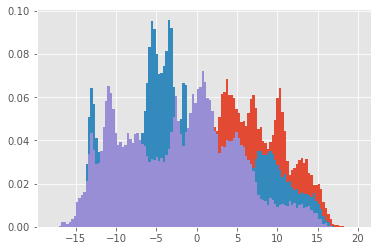

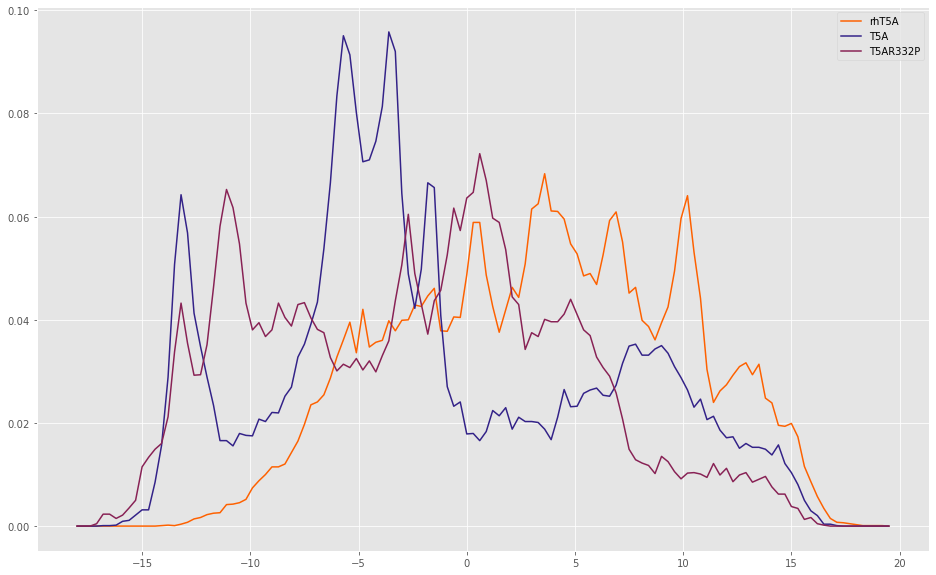

In [54]:
binrange = arange(-18,20,.3)

#system_pcaPoints = pcaPoints.reshape(3,2,int(len(pcaPoints[0])/3)) # For some reason this makes things backwards
system_pc1s=[]
system_pc1s.append(pcaPoints[0][:int(len(pcaPoints[0])/3)])
system_pc1s.append(pcaPoints[0][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)])
system_pc1s.append(pcaPoints[0][2*int(len(pcaPoints[0])/3):])

    
pc1hists=[]
for i in range(len(system_pc1s)):
    a = hist(system_pc1s[i],bins = binrange,density = True)[0]
    pc1hists.append(a)
    
    
    
figure(figsize = (16,10))
for i in range(len(pc1hists)):
    plot(binrange[:-1],pc1hists[i],color = threeColor[i],label = system_names[i])
    
legend()





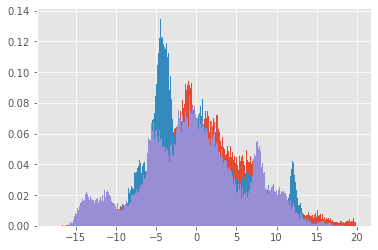

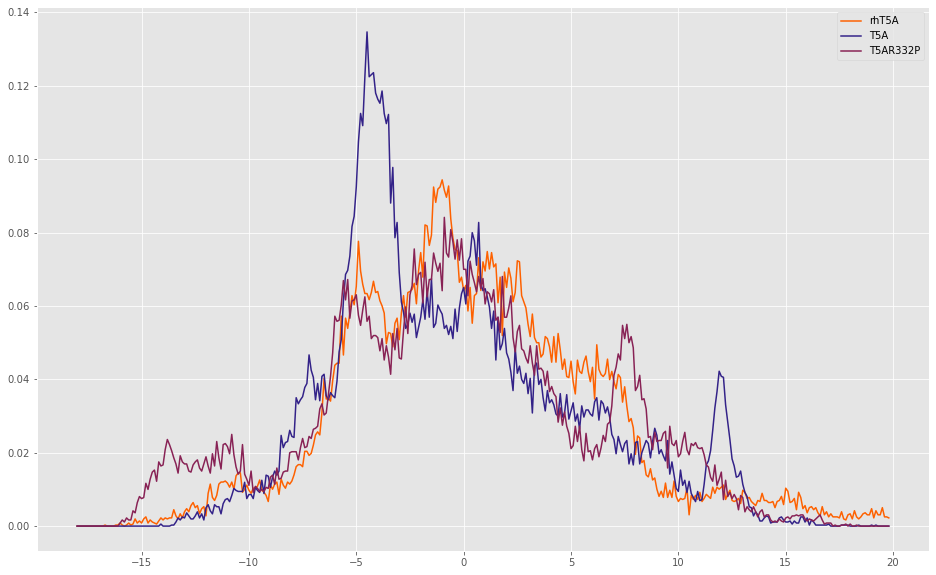

In [55]:
binrange = arange(-18,20,.1)

#system_pcaPoints = pcaPoints.reshape(3,2,int(len(pcaPoints[0])/3)) # For some reason this makes things backwards
system_pc2s=[]
system_pc2s.append(pcaPoints[1][:int(len(pcaPoints[1])/3)])
system_pc2s.append(pcaPoints[1][int(len(pcaPoints[1])/3):2*int(len(pcaPoints[1])/3)])
system_pc2s.append(pcaPoints[1][2*int(len(pcaPoints[1])/3):])

    
pc2hists=[]
for i in range(len(system_pc2s)):
    a = hist(system_pc2s[i],bins = binrange,density = True)[0]
    pc2hists.append(a)
    
    
    
figure(figsize = (16,10))
for i in range(len(pc2hists)):
    plot(binrange[:-1],pc2hists[i],color = threeColor[i],label = system_names[i])
    
legend()





C:\Users\Liam\anaconda3\envs\mda2\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\Liam\anaconda3\envs\mda2\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\Liam\anaconda3\envs\mda2\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.w

Text(0.5, 49.99999999999995, 'PC1')

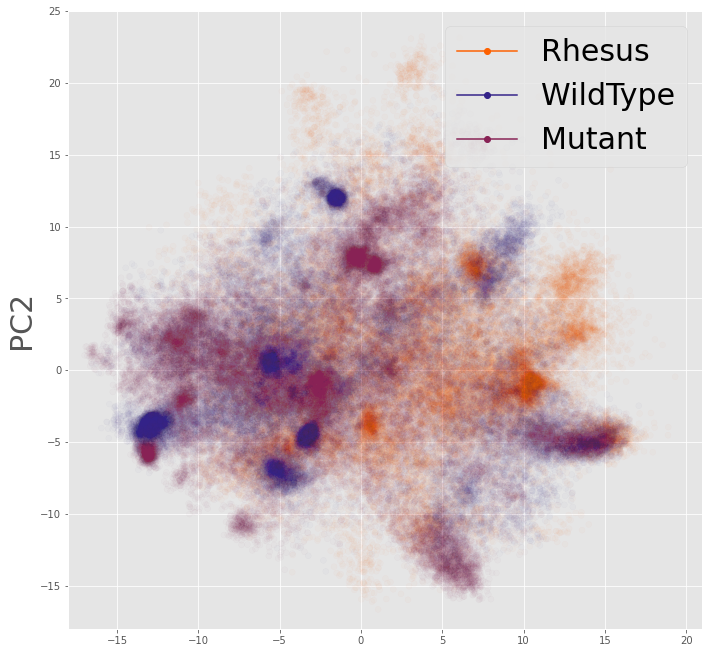

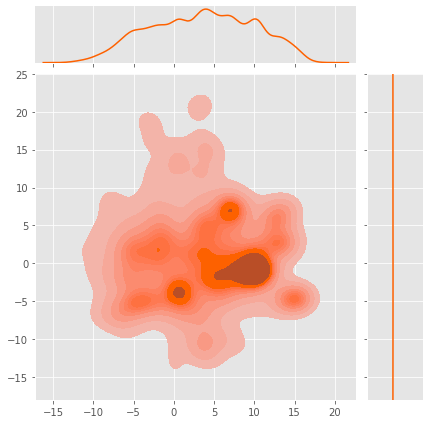

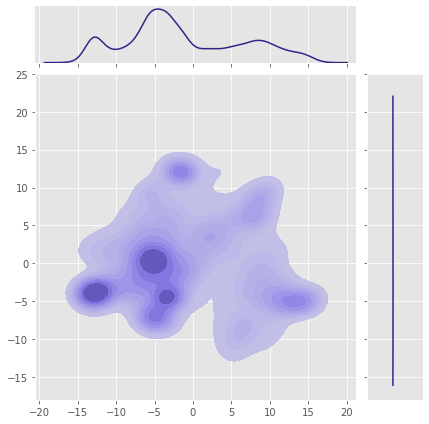

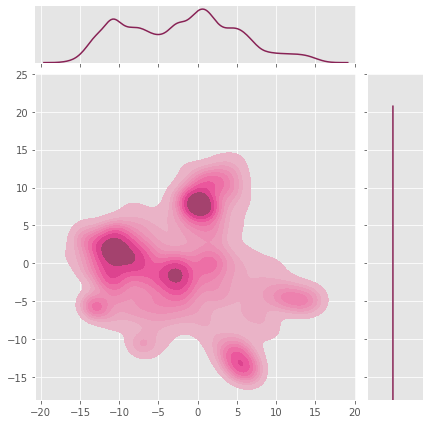

In [9]:
style.use("ggplot")
figure(figsize = (25,25))
#for i in range(len(pcaPoints.T)):
#    scatter(pcaPoints.T[i][0],pcaPoints.T[i][1],color = pca_colours[i],alpha = 0.1)#,color = mycolors[i])#,label = structureList[i][3:])

subplot(2,2,1)
scatter(*pcaPoints,color = pca_colours,alpha = 0.02)
legend_elements = [Line2D([0], [0], marker='o', color=colourScheme[0], label="Rhesus"),
                       Line2D([0], [0], marker='o', color=colourScheme[1], label="WildType"),
                       Line2D([0], [0], marker='o', color=colourScheme[2], label="Mutant")]
legend(handles = legend_elements,loc='best',fontsize = 30)
ylabel("PC2",fontsize = 30)
ylim(-18,25)
xlim(-18,21)
#xticks([])
#yticks([])

sns.jointplot(pcaPoints[0][:int(len(pcaPoints[0])/3)],pcaPoints[1][:int(len(pcaPoints[0])/3)],kind = 'kde',shade = True, color=colourScheme[0])

#xticks([])
#yticks([])
ylim(-18,25)
xlim(-18,21)

sns.jointplot(pcaPoints[0][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],pcaPoints[1][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],kind = 'kde',shade= True, color = colourScheme[1])

#xticks([])
#yticks([])
ylim(-18,25)
xlim(-18,21)
xlabel("PC1",fontsize = 30)
ylabel("PC2",fontsize = 30)


sns.jointplot(pcaPoints[0][2*int(len(pcaPoints[0])/3):],pcaPoints[1][2*int(len(pcaPoints[0])/3):],kind = 'kde',shade = True,color=colourScheme[2])
#xticks([])
#yticks([])
ylim(-18,25)
xlim(-18,21)
xlabel("PC1",fontsize = 30)


In [10]:
def toTwoD_NN(array1D):
    N = int(0.5 + .5*np.sqrt(1+(8*len(array1D))))
    twoD=zeros((N,N))            
    j=1
    k=0
    for i in range(len(array1D)):
        if j != k:
            twoD[j][k] = array1D[i]
            twoD[k][j] = array1D[i]
        #if j==k or j==k+1 or j == k-1:
        #    twoD[j][k]=1
        j+=1
        if j == len(twoD):
            k+=1
            j = k+1
            if k==len(twoD)-1:
                break
    return twoD

([<matplotlib.axis.YTick at 0x2139e27dc60>,
 [Text(0, 0, '324'),
  Text(0, 2, '326'),
  Text(0, 4, '328'),
  Text(0, 6, '330'),
  Text(0, 8, '332'),
  Text(0, 10, '334'),
  Text(0, 12, '336'),
  Text(0, 14, '338'),
  Text(0, 16, '340'),
  Text(0, 18, '342'),
  Text(0, 20, '344')])

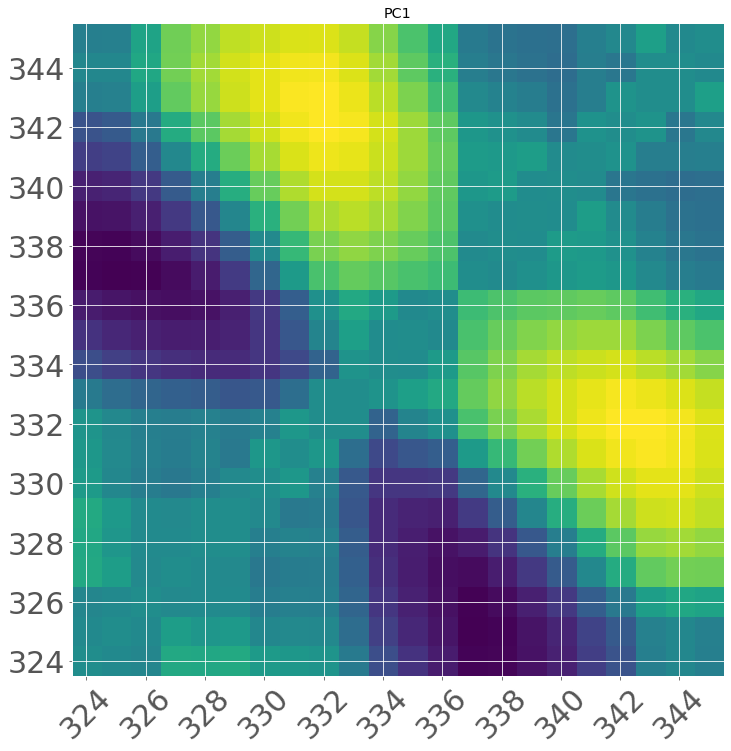

In [11]:
figure(figsize = (12,12))
imshow(toTwoD_NN(myPCA.components_[0]),origin = 'lower')
title("PC1")

xticks(arange(len(v1s[0][0].residues.resids))[::2],v1s[0][0].residues.resids[::2],fontsize = 30,rotation = 45)
yticks(arange(len(v1s[0][0].residues.resids))[::2],v1s[0][0].residues.resids[::2],fontsize = 30)

([<matplotlib.axis.YTick at 0x2139e2f3eb0>,
 [Text(0, 0, '324'),
  Text(0, 2, '326'),
  Text(0, 4, '328'),
  Text(0, 6, '330'),
  Text(0, 8, '332'),
  Text(0, 10, '334'),
  Text(0, 12, '336'),
  Text(0, 14, '338'),
  Text(0, 16, '340'),
  Text(0, 18, '342'),
  Text(0, 20, '344')])

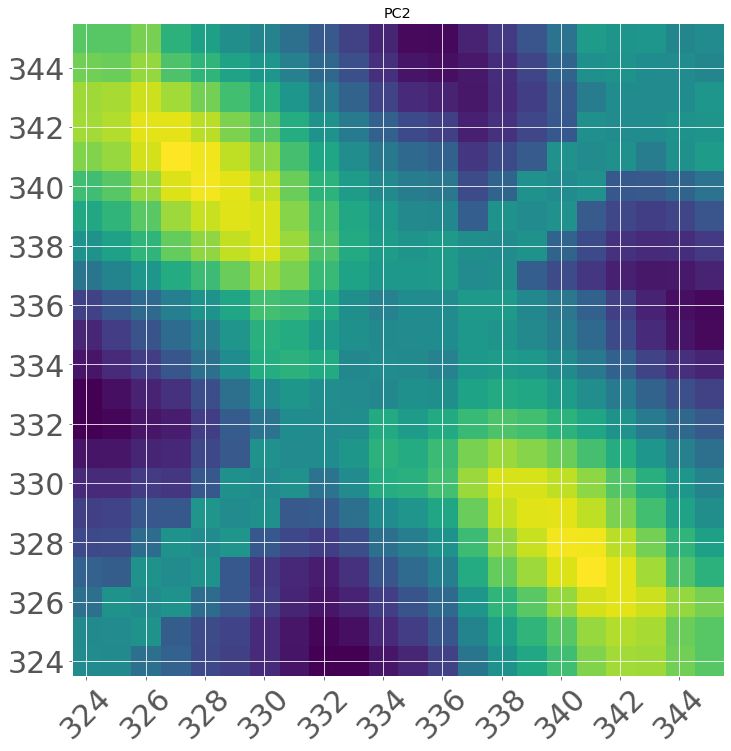

In [12]:
figure(figsize = (12,12))
imshow(toTwoD_NN(myPCA.components_[1]),origin = 'lower')
title("PC2")
xticks(arange(len(v1s[0][0].residues.resids))[::2],v1s[0][0].residues.resids[::2],fontsize = 30,rotation = 45)
yticks(arange(len(v1s[0][0].residues.resids))[::2],v1s[0][0].residues.resids[::2],fontsize = 30)

Text(0.5, 1.0, 'PC2')

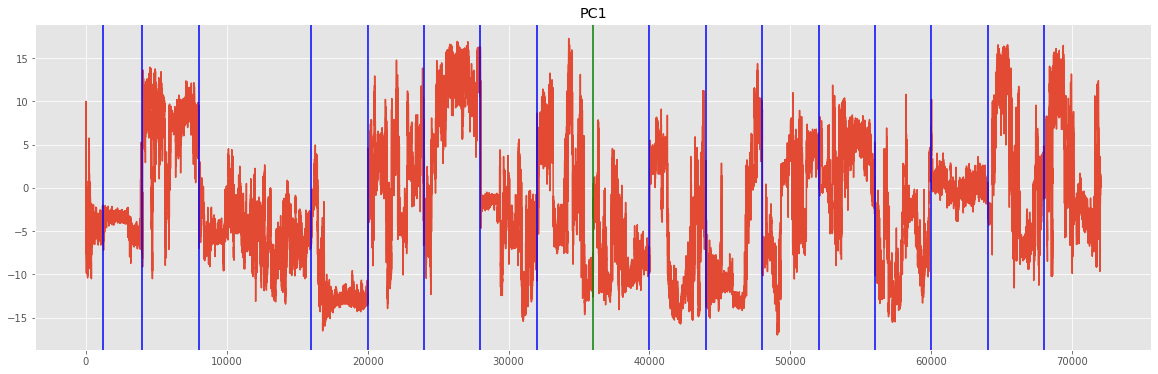

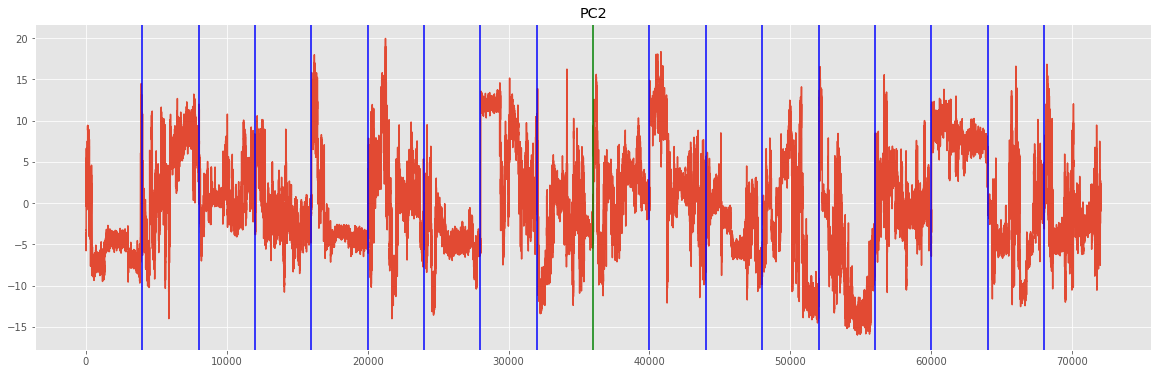

In [13]:
figure(figsize = (20,6))
plot(pcaPoints[0][36000:])
axvline(36000,color = 'green')
axvline(4000,color = 'blue')
axvline(8000,color = 'blue')
axvline(1200,color = 'blue')
axvline(16000,color = 'blue')
axvline(20000,color = 'blue')
axvline(24000,color = 'blue')
axvline(28000,color = 'blue')
axvline(32000,color = 'blue')
axvline(40000,color = 'blue')
axvline(44000,color = 'blue')
axvline(48000,color = 'blue')
axvline(52000,color = 'blue')
axvline(56000,color = 'blue')
axvline(60000,color = 'blue')
axvline(64000,color = 'blue')
axvline(68000,color = 'blue')
title("PC1")

figure(figsize = (20,6))
plot(pcaPoints[1][36000:])
axvline(36000,color = 'green')
axvline(4000,color = 'blue')
axvline(8000,color = 'blue')
axvline(12000,color = 'blue')
axvline(16000,color = 'blue')
axvline(20000,color = 'blue')
axvline(24000,color = 'blue')
axvline(28000,color = 'blue')
axvline(32000,color = 'blue')
axvline(40000,color = 'blue')
axvline(44000,color = 'blue')
axvline(48000,color = 'blue')
axvline(52000,color = 'blue')
axvline(56000,color = 'blue')
axvline(60000,color = 'blue')
axvline(64000,color = 'blue')
axvline(68000,color = 'blue')
title("PC2")


C:\Users\Liam\anaconda3\envs\mda2\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\Liam\anaconda3\envs\mda2\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 49.99999999999995, 'PC1')

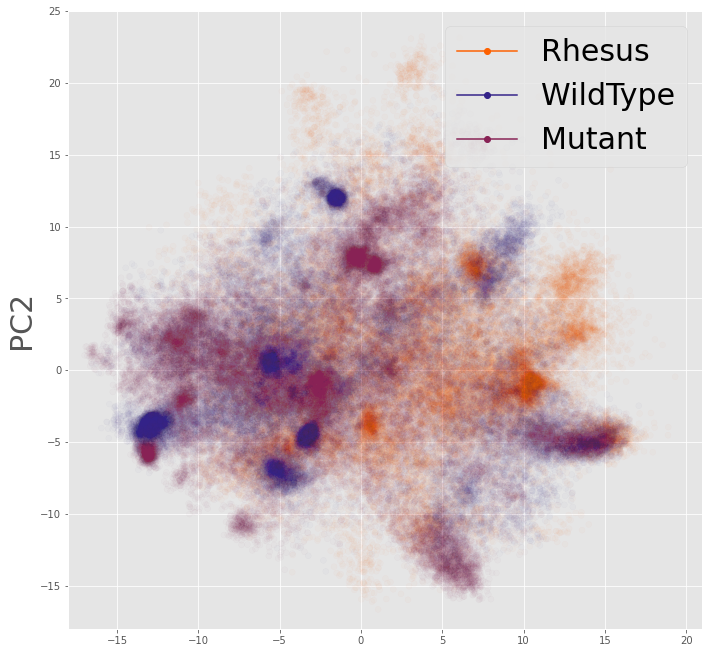

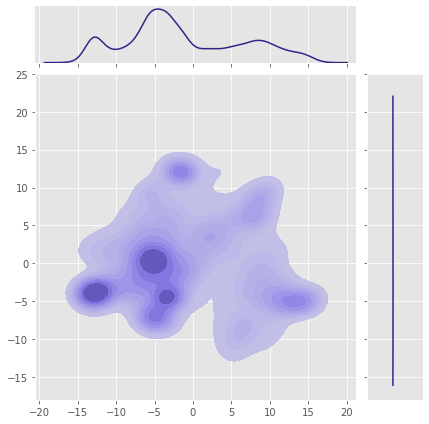

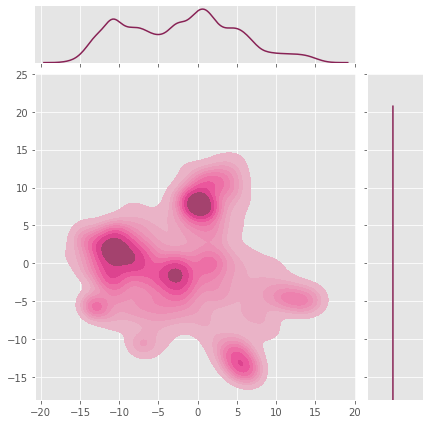

In [14]:
style.use("ggplot")
figure(figsize = (25,25))
#for i in range(len(pcaPoints.T)):
#    scatter(pcaPoints.T[i][0],pcaPoints.T[i][1],color = pca_colours[i],alpha = 0.1)#,color = mycolors[i])#,label = structureList[i][3:])

subplot(2,2,1)
scatter(*pcaPoints,color = pca_colours,alpha = 0.02)
legend_elements = [Line2D([0], [0], marker='o', color=colourScheme[0], label="Rhesus"),
                       Line2D([0], [0], marker='o', color=colourScheme[1], label="WildType"),
                       Line2D([0], [0], marker='o', color=colourScheme[2], label="Mutant")]
legend(handles = legend_elements,loc='best',fontsize = 30)
ylabel("PC2",fontsize = 30)
ylim(-18,25)
xlim(-18,21)
#xticks([])
#yticks([])



sns.jointplot(pcaPoints[0][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],pcaPoints[1][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],kind = 'kde',shade= True, color = colourScheme[1])

#xticks([])
#yticks([])
ylim(-18,25)
xlim(-18,21)
xlabel("PC1",fontsize = 30)
ylabel("PC2",fontsize = 30)


sns.jointplot(pcaPoints[0][2*int(len(pcaPoints[0])/3):],pcaPoints[1][2*int(len(pcaPoints[0])/3):],kind = 'kde',shade = True,color=colourScheme[2])
#xticks([])
#yticks([])
ylim(-18,25)
xlim(-18,21)
xlabel("PC1",fontsize = 30)
